# Business Invoice — Information Extraction Backend

This notebook is the **backend development environment** for the Invoice IE system.
It imports the exact same `pipeline.py` module used by the Streamlit app
(`app.py`), so anything validated here behaves identically in the deployed app.

**Pipeline stages covered:**
1. POS tagging
2. Named Entity Recognition (statistical + invoice-specific regex entities)
3. Entity linking to Wikidata (optional, needs internet access)
4. Relation extraction (dependency-parse rules)
5. Event extraction (trigger lexicon + date association)
6. Temporal ordering (NetworkX DAG + timeline)


In [1]:
import sys
sys.path.append('.')
import pipeline as pl
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 140)

nlp = pl.load_nlp()
print("spaCy pipeline loaded:", nlp.pipe_names)

spaCy pipeline loaded: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## 1. Load a sample invoice

In [2]:
with open('sample_data/invoice_1.txt', encoding='utf-8') as f:
    invoice_text = f.read()

print(invoice_text)

Acme Manufacturing Pvt Ltd, Bangalore, India
Invoice No: INV-2024-1042
Purchase Order PO-88291

Invoice Date: 03 January 2024
Due Date: 02 February 2024

Bill To: Beta Retail Corp, Mumbai, India
GSTIN: 29ABCDE1234F1Z5

Acme Manufacturing issued this invoice to Beta Retail Corp for goods ordered on 20 December 2023.
Beta Retail Corp placed the order through their procurement manager, Rohan Mehta.
The goods were shipped on 27 December 2023 and delivered to the Mumbai warehouse on 30 December 2023.
Beta Retail Corp received the shipment and confirmed delivery on 31 December 2023.

Line Items:
1. Steel Rods (500 units) - $2,500.00
2. Aluminium Sheets (200 units) - $1,800.00

Subtotal: $4,300.00
Tax Amount: $430.00
Total Amount: $4,730.00

Payment Term: Net 30
Beta Retail Corp is expected to pay the total amount by the due date.
Acme Manufacturing will issue a refund if any items are returned within 15 days.



## 2. POS tagging

We use spaCy's statistical tagger to get, per token:
- `pos` — coarse universal POS tag (NOUN, VERB, PROPN, ...)
- `tag` — fine-grained Penn Treebank tag (NNP, VBD, ...)
- `dep` — dependency relation to its syntactic head


In [3]:
pos_df = pl.pos_tag(invoice_text, nlp)
pos_df.head(20)

,token,lemma,pos,tag,dep,head,is_stop
0,Acme,Acme,PROPN,NNP,compound,Ltd,False
1,Manufacturing,Manufacturing,PROPN,NNP,compound,Ltd,False
2,Pvt,Pvt,PROPN,NNP,compound,Ltd,False
3,Ltd,Ltd,PROPN,NNP,ROOT,Ltd,False
4,",",",",PUNCT,",",punct,Ltd,False
5,Bangalore,Bangalore,PROPN,NNP,npadvmod,Ltd,False
6,",",",",PUNCT,",",punct,Bangalore,False
7,India,India,PROPN,NNP,conj,Bangalore,False
8,Invoice,Invoice,PROPN,NNP,nmod,Date,False
9,No,no,NOUN,NN,nmod,Date,True


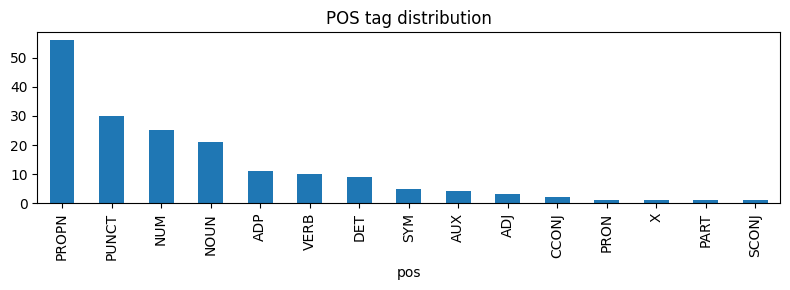

In [4]:
pos_df['pos'].value_counts().plot(kind='bar', figsize=(8,3), title='POS tag distribution')
plt.tight_layout()
plt.show()

## 3. Named Entity Recognition

Two complementary sources of entities are merged:
- **Statistical NER** (spaCy `en_core_web_sm`): PERSON, ORG, GPE/LOC, DATE, MONEY, CARDINAL, ...
- **Regex-based invoice entities**: INVOICE_NUMBER, PO_NUMBER, TAX_ID, AMOUNT, PAYMENT_TERM

Overlaps are resolved so the domain-specific regex entities take priority
(see `extract_entities()` / `_custom_regex_spans()` in `pipeline.py`).


In [5]:
doc, entities_df = pl.extract_entities(invoice_text, nlp)
entities_df

,text,label,start_char,end_char
0,Acme Manufacturing Pvt Ltd,ORGANIZATION,0,26
1,Bangalore,LOCATION,28,37
2,India,LOCATION,39,44
3,Invoice,LOCATION,45,52
4,INV-2024-1042,INVOICE_NUMBER,57,70
5,PO-88291,PO_NUMBER,86,94
6,03 January 2024,DATE,110,125
7,02 February 2024,DATE,136,152
8,Bill,PERSON,154,158
9,Mumbai,LOCATION,181,187


In [6]:
from spacy import displacy
html = pl.render_entities_html(doc)
from IPython.display import HTML
HTML(html)

## 4. Entity linking to Wikidata (optional)

`link_entities()` queries the public Wikidata REST API (`wbsearchentities`)
for each ORGANIZATION / PERSON / LOCATION entity and attaches a QID,
description, and URL. This requires outbound internet access to
`www.wikidata.org` — if unavailable (e.g. a sandboxed environment), the
function fails silently and returns `None` for that entity so the rest of
the pipeline is unaffected.


In [7]:
# Toggle this to True if you have outbound internet access to wikidata.org
DO_ENTITY_LINKING = False

if DO_ENTITY_LINKING:
    linked_df = pl.link_entities(entities_df)
    display(linked_df[linked_df['wikidata_qid'].notna()])
else:
    print("Entity linking skipped (DO_ENTITY_LINKING=False). See pipeline.link_entities().")

Entity linking skipped (DO_ENTITY_LINKING=False). See pipeline.link_entities().


## 5. Relation extraction

Rule-based extraction over the dependency parse:
- **SVO triples**: subject --verb--> object, verb lemma mapped to a canonical
  relation (e.g. `issue` → `ISSUED_BY`, `ship` → `SHIPPED_TO`).
- **Field linking**: proximity-based rules that connect the implicit
  `INVOICE` document node to nearby AMOUNT / DATE fields (e.g.
  "Total Amount: $4,730.00" → `(INVOICE, HAS_AMOUNT, $4,730.00)`).


In [8]:
relations_df = pl.extract_relations(doc)
relations_df

,subject,subject_label,relation,object,object_label,evidence
0,To,NOUN,ISSUED_BY,invoice,NOUN,"Bill To: Beta Retail Corp, Mumbai, India\nGSTIN: 29ABCDE1234F1Z5\n\nAcme Man..."
1,Beta Retail Corp,ORG,PLACE,order,NOUN,"Beta Retail Corp placed the order through their procurement manager, Rohan M..."
2,goods,NOUN,SHIPPED_TO,27 December 2023,DATE,The goods were shipped on 27 December 2023 and delivered to the Mumbai wareh...
3,Beta Retail Corp,ORG,RECEIVE,shipment,NOUN,Beta Retail Corp received the shipment and confirmed delivery on 31 December...
4,Acme Manufacturing,ORG,ISSUED_BY,refund,NOUN,Acme Manufacturing will issue a refund if any items are returned within 15 d...
5,items,NOUN,RETURN,15 days,DATE,Acme Manufacturing will issue a refund if any items are returned within 15 d...
6,INVOICE,DOCUMENT,HAS_DATE,03 January 2024,DATE,Purchase Order PO-88291\n\nInvoice Date: 03 January 2024
7,INVOICE,DOCUMENT,HAS_DATE,02 February 2024,DATE,Invoice Date: 03 January 2024\nDue Date: 02 February 2024
8,INVOICE,DOCUMENT,HAS_AMOUNT,"$4,300.00",AMOUNT,"eets (200 units) - $1,800.00\n\nSubtotal: $4,300.00"
9,INVOICE,DOCUMENT,HAS_AMOUNT,$430.00,AMOUNT,"800.00\n\nSubtotal: $4,300.00\nTax Amount: $430.00"


## 6. Event extraction

A small trigger lexicon (`EVENT_TRIGGERS` in `pipeline.py`) maps verbs/nouns
like *issue*, *ship*, *deliver*, *pay*, *due* to canonical business-invoice
event types (`InvoiceIssued`, `GoodsShipped`, `PaymentDue`, ...). Each
detected trigger is associated with the nearest DATE entity in the same
sentence.


In [9]:
events_df = pl.extract_events(doc)
events_df[['event_type', 'trigger', 'date_text', 'date_parsed']]

,event_type,trigger,date_text,date_parsed
0,InvoiceIssued,issued,20 December 2023,2023-12-20
1,OrderPlaced,ordered,20 December 2023,2023-12-20
2,OrderPlaced,placed,20 December 2023,2023-12-20
3,GoodsShipped,shipped,27 December 2023,2023-12-27
4,GoodsDelivered,delivered,27 December 2023,2023-12-27
5,GoodsReceived,received,31 December 2023,2023-12-31
6,PaymentMade,pay,15 days,NaT
7,PaymentDue,due,15 days,NaT
8,InvoiceIssued,issue,15 days,NaT
9,RefundIssued,refund,15 days,NaT


## 7. Temporal ordering

Events are sorted by their resolved calendar date (durations like *"15
days"* or payment terms like *"Net 30"* are deliberately excluded from
date resolution — see `_try_parse_date()` — since they are not absolute
timestamps). A NetworkX directed graph then encodes a simple `BEFORE`
precedence chain across the ordered events, which the Streamlit app renders
as a timeline.


In [10]:
ordered_events_df, graph = pl.build_temporal_order(events_df)
ordered_events_df[['sequence', 'event_type', 'date_text', 'date_parsed']]

,sequence,event_type,date_text,date_parsed
0,1,InvoiceIssued,20 December 2023,2023-12-20
1,2,OrderPlaced,20 December 2023,2023-12-20
2,3,OrderPlaced,20 December 2023,2023-12-20
3,4,GoodsShipped,27 December 2023,2023-12-27
4,5,GoodsDelivered,27 December 2023,2023-12-27
5,6,GoodsReceived,31 December 2023,2023-12-31
6,7,PaymentMade,15 days,NaT
7,8,PaymentDue,15 days,NaT
8,9,InvoiceIssued,15 days,NaT
9,10,RefundIssued,15 days,NaT


/tmp/ipykernel_544/2538206122.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


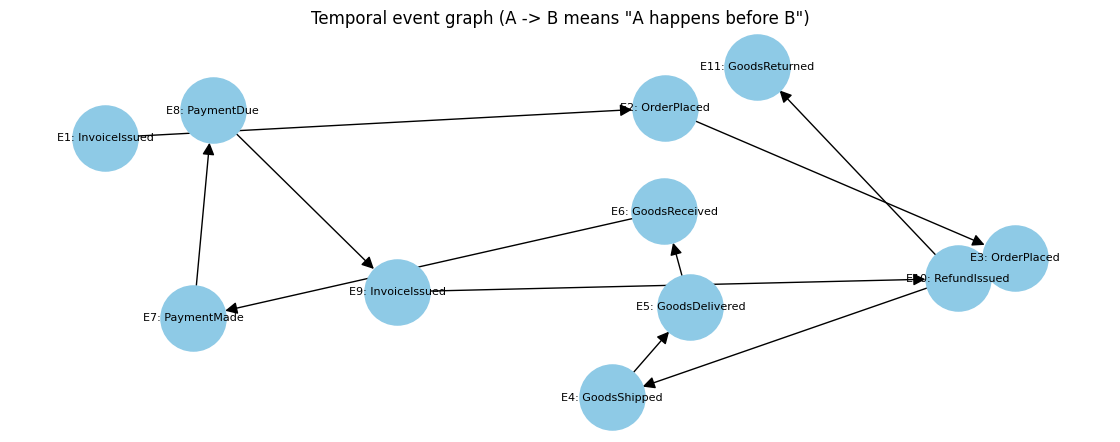

In [11]:
plt.figure(figsize=(11, 4))
pos = nx.spring_layout(graph, k=1.6, seed=7)
nx.draw(graph, pos, with_labels=True, node_color='#8ecae6', node_size=2200,
        font_size=8, arrowsize=18)
plt.title('Temporal event graph (A -> B means "A happens before B")')
plt.tight_layout()
plt.show()

### 7.1 Milestone timeline diagram

A plain scatter plot collides when several events share the same date (or
have no date at all) -- labels overlap into unreadable text. This plotter
fixes that: it places each event's label on a vertical "stem" whose height
cycles through several levels *in sequence order* (not date order), so
same-date events always land on different rows, and it fans out any
undated events to the right of the timeline (clearly marked "date
unresolved") instead of silently dropping them.


In [12]:
timeline_fig = pl.render_event_timeline_figure(ordered_events_df, graph)
timeline_fig.show()

## 8. Knowledge graph

Every extracted relation `(subject, relation, object)` becomes an edge in
a `networkx.MultiDiGraph`, with entity-type metadata pulled from the NER
table for node coloring. This synthesizes stages 2 (NER) and 4 (relation
extraction) into a single connected structure — the closest thing this
pipeline produces to a per-invoice mini knowledge base.


In [13]:
knowledge_graph = pl.build_knowledge_graph(entities_df, relations_df)
stats = pl.knowledge_graph_stats(knowledge_graph)
print(f"Nodes: {stats['nodes']}   Edges: {stats['edges']}")
stats['top_entities'].head(10)

Nodes: 17   Edges: 11


,entity,type,connections,centrality
0,INVOICE,DOCUMENT,5,0.312
1,Beta Retail Corp,ORGANIZATION,2,0.125
2,To,NOUN,1,0.062
3,order,NOUN,1,0.062
4,invoice,NOUN,1,0.062
5,27 December 2023,DATE,1,0.062
6,shipment,NOUN,1,0.062
7,Acme Manufacturing,ORGANIZATION,1,0.062
8,goods,NOUN,1,0.062
9,refund,NOUN,1,0.062


/tmp/ipykernel_544/937079013.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


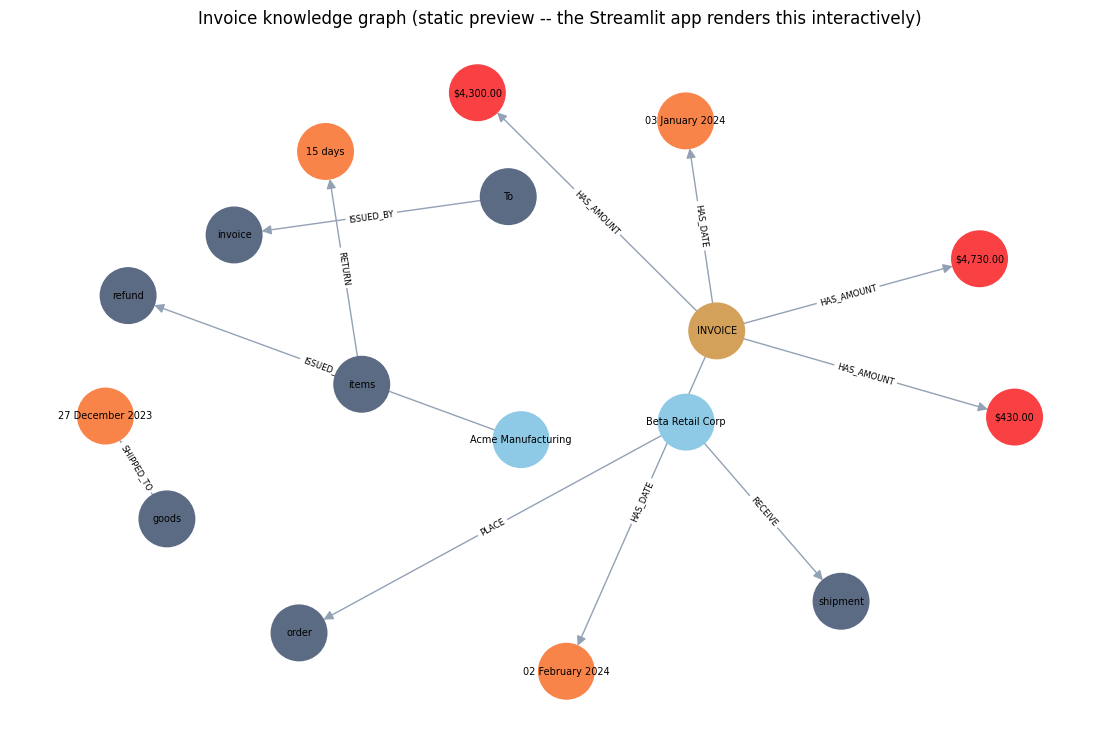

In [14]:
plt.figure(figsize=(11, 7))
pos = nx.spring_layout(knowledge_graph, k=1.1, seed=3)
node_colors = [pl.KG_NODE_COLORS.get(d.get('label','OTHER'), '#5C6B84') for _, d in knowledge_graph.nodes(data=True)]
nx.draw(knowledge_graph, pos, with_labels=True, node_color=node_colors, node_size=1600,
        font_size=7, arrowsize=14, edge_color='#93A1B5')
edge_labels = {(u, v): d['relation'] for u, v, d in knowledge_graph.edges(data=True)}
nx.draw_networkx_edge_labels(knowledge_graph, pos, edge_labels=edge_labels, font_size=6)
plt.title('Invoice knowledge graph (static preview -- the Streamlit app renders this interactively)')
plt.tight_layout()
plt.show()

The Streamlit app (`app.py`) renders this same graph interactively via
`pyvis` (draggable nodes, hover tooltips with the supporting sentence,
degree-scaled node size) in the **Knowledge Graph** tab.


## 8. Run the full pipeline in one call (used by app.py)

In [15]:
result = pl.run_pipeline(invoice_text, nlp=nlp, do_entity_linking=False)
print(result.keys())

dict_keys(['doc', 'pos_df', 'entities_df', 'relations_df', 'events_df', 'temporal_graph', 'knowledge_graph'])


## 9. Batch test on a second invoice (different vendor / currency / flow)

This validates the pipeline generalizes beyond a single hand-tuned example.


In [16]:
with open('sample_data/invoice_2.txt', encoding='utf-8') as f:
    invoice_text_2 = f.read()

result_2 = pl.run_pipeline(invoice_text_2, nlp=nlp)
display(result_2['entities_df'])
display(result_2['relations_df'])
display(result_2['events_df'][['sequence','event_type','date_text']])

,text,label,start_char,end_char
0,Global Tech Supplies Inc,ORGANIZATION,0,24
1,San Francisco,LOCATION,26,39
2,USA,LOCATION,41,44
3,INV-7788,INVOICE_NUMBER,61,69
4,PO Number,FAC,70,79
5,PO-3391,PO_NUMBER,81,88
6,15 May 2024,DATE,104,115
7,14 June 2024,DATE,126,138
8,Bill,PERSON,140,144
9,Nova Electronics,ORGANIZATION,149,165


,subject,subject_label,relation,object,object_label,evidence
0,Global Tech Supplies Inc,ORG,SOLD_TO,laptops,NOUN,"Global Tech Supplies Inc, San Francisco, USA\nInvoice Number: INV-7788\nPO N..."
1,Nova Electronics,ORG,ORDERED_BY,equipment,NOUN,Nova Electronics ordered the equipment on 01 May 2024.
2,Global Tech Supplies,ORG,DISPATCH,shipment,NOUN,Global Tech Supplies dispatched the shipment on 10 May 2024.
3,equipment,NOUN,DELIVERED_TO,Nova Electronics,ORG,The equipment was delivered to Nova Electronics on 13 May 2024.
4,Nova Electronics,ORG,PAID_BY,invoice,NOUN,Nova Electronics paid the invoice in full on 20 May 2024.
5,INVOICE,DOCUMENT,HAS_DATE,15 May 2024,DATE,-7788\nPO Number: PO-3391\n\nInvoice Date: 15 May 2024
6,INVOICE,DOCUMENT,HAS_DATE,14 June 2024,DATE,91\n\nInvoice Date: 15 May 2024\nDue Date: 14 June 2024
7,INVOICE,DOCUMENT,HAS_AMOUNT,"$10,700.00",AMOUNT,"h (10 units) - $1,200.00\n\nTotal Amount: $10,700.00"


,sequence,event_type,date_text
0,1,OrderPlaced,01 May 2024
1,2,GoodsShipped,10 May 2024
2,3,GoodsDelivered,13 May 2024
3,4,PaymentMade,20 May 2024


## 10. Export tables (for the report / deliverables)


In [17]:
entities_df.to_csv('sample_data/invoice_1_entities.csv', index=False)
relations_df.to_csv('sample_data/invoice_1_relations.csv', index=False)
ordered_events_df.drop(columns=['date_parsed']).to_csv('sample_data/invoice_1_events.csv', index=False)
print("Exported entities/relations/events CSVs to sample_data/")

Exported entities/relations/events CSVs to sample_data/
